# Example 02_weekdays_vs_average

Real data (paper Fig. 7). Detector 78, November 2016: twelve complete weekdays beside the average-weekday profile built from exactly those days. The averaged-profile episode is not the average of the daily episodes.

This notebook runs `run.py` in this folder and shows its outputs. Inputs are in `config.json`; expected values are in `expected/results.json`.

In [1]:
import json, runpy, sys
from pathlib import Path
from IPython.display import Image, display
HERE = Path.cwd()
try:
    runpy.run_path(str(HERE / 'run.py'), run_name='__main__')
except SystemExit as e:
    print('exit status', e.code)

REAL DATA: detector 78, November 2016, 12 complete weekdays (legacy ADOT data, research use)
1. monthly profile from the drawn days: max relative difference flow 2.9e-16, speed 5.5e-10 -> PASS
2. 11 daily PM episodes on 12 days (no PM episode on 2016-11-11; that day's congestion was detected in another period).
   PM episodes: P from 4.33 to 6.17 h (mean 5.32 h), mean D 5683 veh/lane, mean of daily minimum speeds 4.6 mph
   averaged-profile episode 14:35-19:20: P = 4.75 h, D = 5003 veh/lane; minimum averaged speed 6.7 mph
   The averaged profile is one calibration target; its episode is not the average of the daily episode metrics.


compared 17 values with expected/results.json: 17 agree
exit status 0


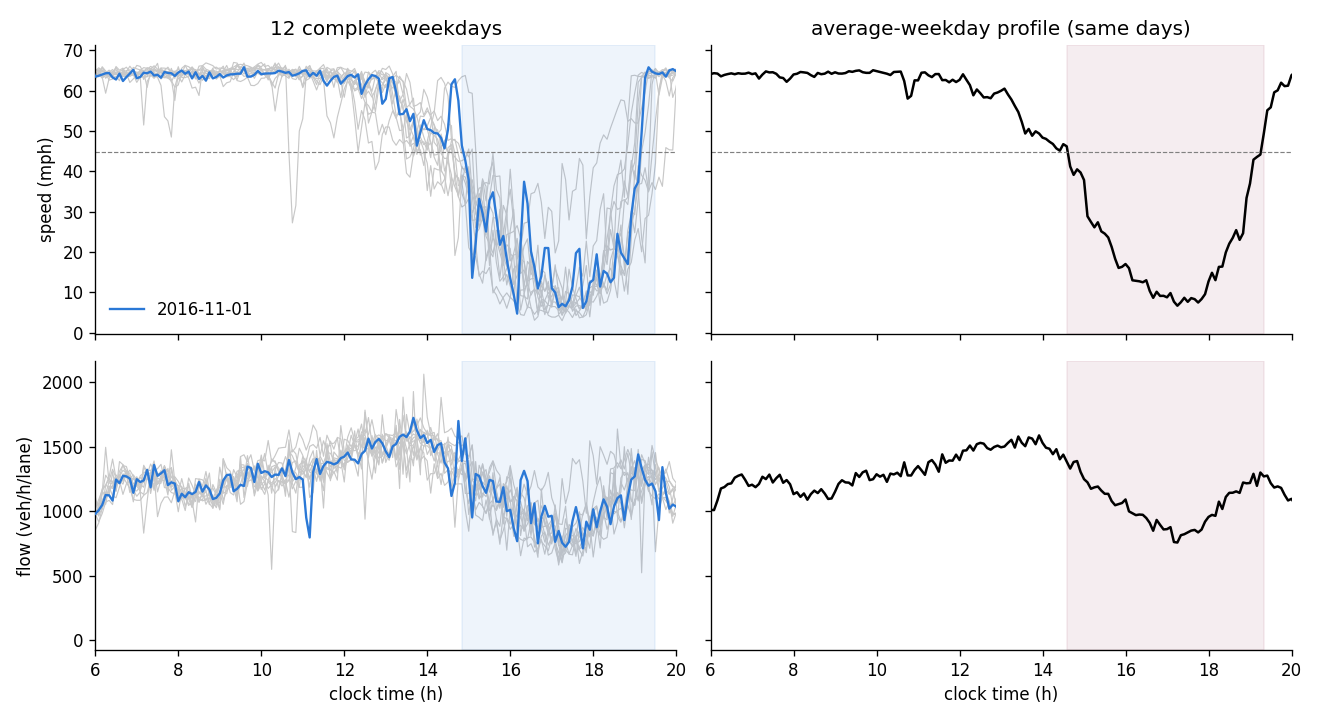

In [2]:
display(Image(filename=str(HERE / 'figure.png')))

In [3]:
res = json.loads((HERE / 'results.json').read_text())
print(json.dumps({k: v for k, v in res.items() if k != 'provenance'}, indent=1)[:3000])
print('provenance:', res['provenance'])

{
 "n_days": 12,
 "bins": 288,
 "profile_check": {
  "flow_max_rel_diff": 2.8647306972814925e-16,
  "speed_max_rel_diff": 5.479766725315579e-10,
  "passes": true
 },
 "days_without_pm_episode": [
  "2016-11-11"
 ],
 "daily_pm_episodes": {
  "count": 11,
  "P_h_mean": 5.318181818272728,
  "P_h_min": 4.333333333,
  "P_h_max": 6.166666667,
  "D_veh_mean": 5683.054545454545,
  "mean_delay_min_mean": 2.828292344781818,
  "min_speed_mph_mean": 4.577229798181818
 },
 "average_profile_episode": {
  "t0": "14:35",
  "t3": "19:20",
  "P_h": 4.75,
  "D_veh": 5003.016666666666
 },
 "average_profile_min_speed_mph": 6.686485005
}
provenance: {'paper': 'Abbasi, M., Zhou, X. (2026). From Bottleneck Episodes to Travel and Emission Costs: A Cross-Resolution Framework with Empirical Evaluation.', 'qvdfe_version': '1.0.1', 'commit': 'unknown'}
